📊 Análise de Desempenho de Lojas – Projeto Sr. João

Objetivo:
Este notebook tem como objetivo analisar o desempenho de quatro lojas a partir dos dados fornecidos pelo Sr. João, com o intuito de identificar qual loja apresenta os piores resultados e, portanto, seria a mais indicada para ser vendida.

Dados analisados:

1. Faturamento total por loja

2. Volume de vendas por categoria

3. Avaliação média dos clientes

4. Produtos mais e menos vendidos

5. Custo médio de frete por loja

Metodologia:
A análise foi feita utilizando bibliotecas de manipulação e visualização de dados do python. Pandas e matplotlib

Os dados foram limpos e organizados para facilitar a interpretação e a tomada de decisão.

# **0. Importando os dados**


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


# **1. Faturamento**

### **Faturamento total por loja**

In [36]:
# Função para formatar valores em reais
def formatar_em_reais(valor):
    return f'R$ {valor:,.2f}'

# Função para calcular a porcentagem de cada loja sobre o faturamento total
def calcular_porcentagem(faturamento, total):
    return (faturamento / total) * 100

# Calcular o faturamento total de cada loja
faturamento_loja1 = loja['Preço'].sum()
faturamento_loja2 = loja2['Preço'].sum()
faturamento_loja3 = loja3['Preço'].sum()
faturamento_loja4 = loja4['Preço'].sum()

# Calcular o faturamento total das 4 lojas
faturamento_total = faturamento_loja1 + faturamento_loja2 + faturamento_loja3 + faturamento_loja4

# Criar a tabela com o faturamento de cada loja
faturamento_tabela = pd.DataFrame({
    'Loja': ['LOJA1', 'LOJA2', 'LOJA3', 'LOJA4'],
    'Faturamento': [faturamento_loja1, faturamento_loja2, faturamento_loja3, faturamento_loja4]
})

# Calcular a porcentagem de cada loja sobre o faturamento total
faturamento_tabela['Porcentagem'] = faturamento_tabela['Faturamento'].apply(lambda x: calcular_porcentagem(x, faturamento_total))

# Adicionar a linha "Total" com o faturamento total e a porcentagem de 100%
faturamento_tabela.loc['Total'] = ['Total', faturamento_total, 100.00]

# Formatando a coluna de faturamento para exibir em reais (R$)
faturamento_tabela['Faturamento'] = faturamento_tabela['Faturamento'].apply(formatar_em_reais)
faturamento_tabela.loc['Total', 'Faturamento'] = formatar_em_reais(faturamento_total)

# Formatar a porcentagem
faturamento_tabela['Porcentagem'] = faturamento_tabela['Porcentagem'].apply(lambda x: f'{x:.2f}%')

# Exibir a tabela final
display(faturamento_tabela)

,Loja,Faturamento,Porcentagem
0,LOJA1,"R$ 1,534,509.12",26.13%
1,LOJA2,"R$ 1,488,459.06",25.35%
2,LOJA3,"R$ 1,464,025.03",24.93%
3,LOJA4,"R$ 1,384,497.58",23.58%
Total,Total,"R$ 5,871,490.79",100.00%


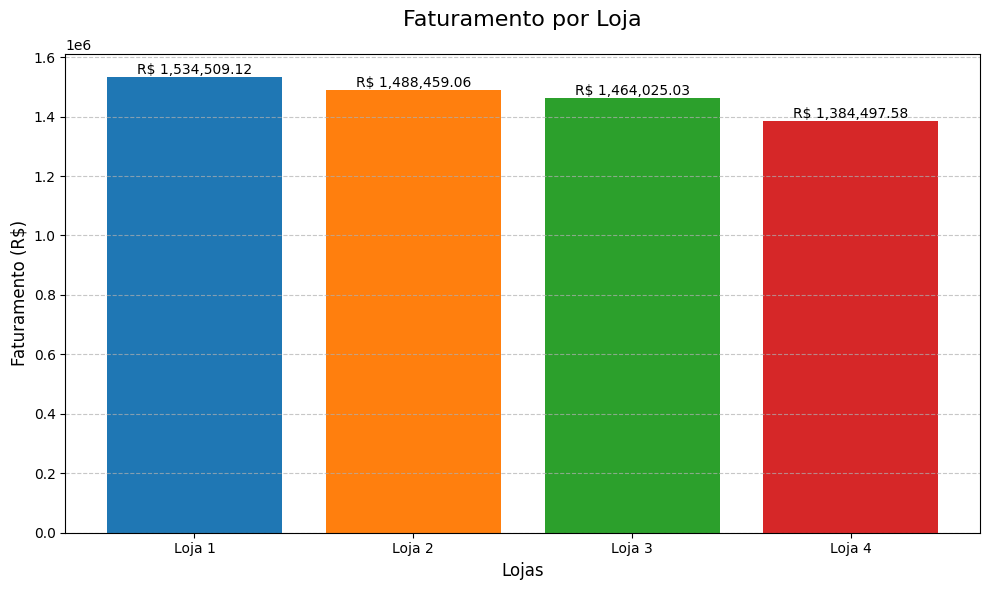

In [37]:

# Dados
lojas = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']
faturamentos = [faturamento_loja1, faturamento_loja2, faturamento_loja3, faturamento_loja4]

# Criar o gráfico
plt.figure(figsize=(10, 6))  # Tamanho do gráfico
bars = plt.bar(lojas, faturamentos, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

# Adicionar rótulos e título
plt.title('Faturamento por Loja', fontsize=16, pad=20)
plt.xlabel('Lojas', fontsize=12)
plt.ylabel('Faturamento (R$)', fontsize=12)

# Adicionar valores em cima das barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'R$ {height:,.2f}',
             ha='center', va='bottom', fontsize=10)

# Ajustar e mostrar
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Análise de faturamento por estado**

In [38]:
lojas = {
    'Loja 1': loja,
    'Loja 2': loja2,
    'Loja 3': loja3,
    'Loja 4': loja4
}

# Dicionário para armazenar os faturamentos por estado de cada loja
resultados = {}

for nome_loja, df_loja in lojas.items():
    # Calcular faturamento por estado (soma dos preços)
    faturamento_estado = df_loja.groupby('Local da compra')['Preço'].sum().reset_index(name='Faturamento')

    # Ordenar do maior para o menor
    faturamento_estado = faturamento_estado.sort_values('Faturamento', ascending=False)

    # Adicionar coluna formatada
    faturamento_estado['Faturamento (R$)'] = faturamento_estado['Faturamento'].apply(lambda x: f'R$ {x:,.2f}')

    # Armazenar no dicionário de resultados
    resultados[nome_loja] = faturamento_estado[['Local da compra', 'Faturamento (R$)']]

    # Mostrar tabela
    print(f"\n=== {nome_loja} ===")
    print(f"Faturamento Total: R$ {df_loja['Preço'].sum():,.2f}")
    display(faturamento_estado[['Local da compra', 'Faturamento (R$)']])


=== Loja 1 ===
Faturamento Total: R$ 1,534,509.12


,Local da compra,Faturamento (R$)
24,SP,"R$ 586,673.21"
18,RJ,"R$ 230,010.44"
10,MG,"R$ 165,802.37"
21,RS,"R$ 111,347.05"
17,PR,"R$ 94,643.66"
22,SC,"R$ 56,332.09"
8,GO,"R$ 50,505.47"
4,BA,"R$ 43,877.34"
6,DF,"R$ 29,729.23"
15,PE,"R$ 23,439.02"



=== Loja 2 ===
Faturamento Total: R$ 1,488,459.06


,Local da compra,Faturamento (R$)
24,SP,"R$ 639,945.67"
17,RJ,"R$ 205,460.97"
9,MG,"R$ 190,868.54"
21,RS,"R$ 93,717.23"
16,PR,"R$ 63,959.90"
22,SC,"R$ 40,981.16"
7,GO,"R$ 38,655.95"
3,BA,"R$ 36,988.86"
14,PE,"R$ 31,860.41"
5,DF,"R$ 28,731.32"



=== Loja 3 ===
Faturamento Total: R$ 1,464,025.03


,Local da compra,Faturamento (R$)
25,SP,"R$ 634,081.24"
10,MG,"R$ 168,270.00"
18,RJ,"R$ 165,838.02"
17,PR,"R$ 74,798.72"
22,RS,"R$ 70,918.92"
4,BA,"R$ 49,024.00"
7,ES,"R$ 47,107.74"
6,DF,"R$ 45,525.91"
23,SC,"R$ 36,231.08"
8,GO,"R$ 33,554.18"



=== Loja 4 ===
Faturamento Total: R$ 1,384,497.58


,Local da compra,Faturamento (R$)
23,SP,"R$ 559,106.82"
17,RJ,"R$ 170,103.47"
9,MG,"R$ 165,874.01"
20,RS,"R$ 91,628.58"
16,PR,"R$ 74,354.88"
21,SC,"R$ 60,857.36"
3,BA,"R$ 46,163.60"
14,PE,"R$ 34,079.71"
5,DF,"R$ 32,516.38"
6,ES,"R$ 24,655.86"


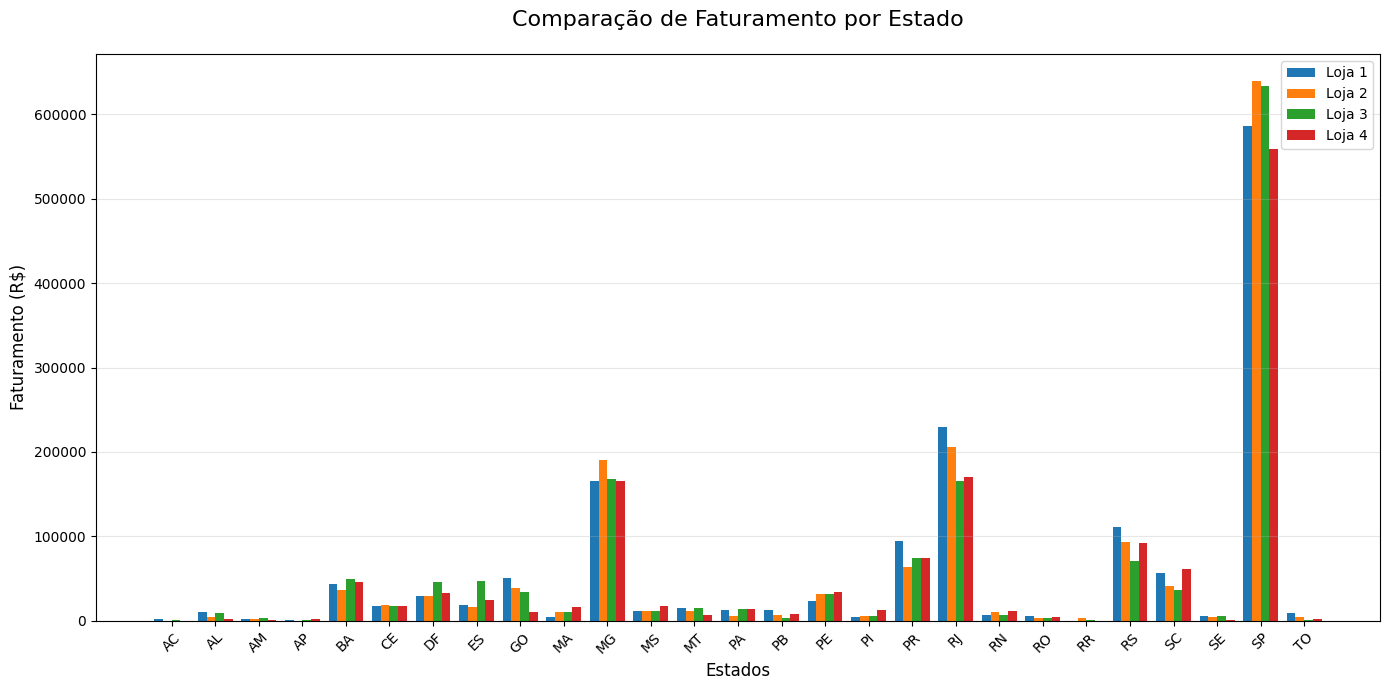

In [39]:

# Dados das lojas
lojas = {
    'Loja 1': loja,
    'Loja 2': loja2,
    'Loja 3': loja3,
    'Loja 4': loja4
}

# Obter todos os estados únicos
estados = sorted(list(set(loja['Local da compra'].unique()) |
                     set(loja2['Local da compra'].unique()) |
                     set(loja3['Local da compra'].unique()) |
                     set(loja4['Local da compra'].unique())))

# Configurações do gráfico
bar_width = 0.2
index = np.arange(len(estados))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

plt.figure(figsize=(14, 7))

# Criar as barras para cada loja
for i, (nome_loja, df_loja) in enumerate(lojas.items()):
    faturamentos = [df_loja[df_loja['Local da compra'] == estado]['Preço'].sum()
                   for estado in estados]
    plt.bar(index + i * bar_width, faturamentos, bar_width,
            label=nome_loja, color=colors[i])

# Personalização
plt.title('Comparação de Faturamento por Estado', fontsize=16, pad=20)
plt.xlabel('Estados', fontsize=12)
plt.ylabel('Faturamento (R$)', fontsize=12)
plt.xticks(index + bar_width * 1.5, estados, rotation=45 if len(estados) > 5 else 0)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

### **Análise dos meios de pagamento preferenciais dos clientes por loja.**

In [40]:
# Dados
lojas = {
    'Loja 1': loja,
    'Loja 2': loja2,
    'Loja 3': loja3,
    'Loja 4': loja4
}

# Processar cada loja
for nome_loja, df_loja in lojas.items():
    print(f"\n=== {nome_loja} ===\n")

    # Calcular faturamento total da loja
    total_loja = df_loja['Preço'].sum()

    # Agrupar por tipo de pagamento
    faturamento = df_loja.groupby('Tipo de pagamento')['Preço'].agg(
        ['sum', 'count']
    ).rename(columns={
        'sum': 'Faturamento (R$)',
        'count': 'Qtd Vendas'
    })

    # Calcular porcentagem e formatar
    faturamento['% do Total'] = (faturamento['Faturamento (R$)'] / total_loja * 100).round(2)
    faturamento['Faturamento (R$)'] = faturamento['Faturamento (R$)'].apply(lambda x: f'R$ {x:,.2f}')
    faturamento['% do Total'] = faturamento['% do Total'].apply(lambda x: f'{x}%')

    # Adicionar linha de TOTAL
    faturamento.loc['TOTAL'] = {
        'Faturamento (R$)': f'R$ {total_loja:,.2f}',
        'Qtd Vendas': df_loja.shape[0],
        '% do Total': '100%'
    }

    # Ordenar do maior para o menor faturamento (excluindo o TOTAL)
    faturamento = pd.concat([
        faturamento.drop('TOTAL').sort_values('Faturamento (R$)', ascending=False),
        faturamento.loc[['TOTAL']]
    ])

    display(faturamento)


=== Loja 1 ===



,Faturamento (R$),Qtd Vendas,% do Total
Tipo de pagamento,,,
cupom,"R$ 85,475.32",137,5.57%
boleto,"R$ 310,147.09",483,20.21%
cartao_debito,"R$ 17,999.05",35,1.17%
cartao_credito,"R$ 1,120,887.66",1704,73.05%
TOTAL,"R$ 1,534,509.12",2359,100%



=== Loja 2 ===



,Faturamento (R$),Qtd Vendas,% do Total
Tipo de pagamento,,,
boleto,"R$ 280,998.45",467,18.88%
cartao_debito,"R$ 15,424.99",30,1.04%
cupom,"R$ 103,156.31",141,6.93%
cartao_credito,"R$ 1,088,879.31",1721,73.15%
TOTAL,"R$ 1,488,459.06",2359,100%



=== Loja 3 ===



,Faturamento (R$),Qtd Vendas,% do Total
Tipo de pagamento,,,
cupom,"R$ 63,215.19",101,4.32%
boleto,"R$ 305,762.67",468,20.89%
cartao_debito,"R$ 22,286.70",37,1.52%
cartao_credito,"R$ 1,072,760.47",1753,73.27%
TOTAL,"R$ 1,464,025.03",2359,100%



=== Loja 4 ===



,Faturamento (R$),Qtd Vendas,% do Total
Tipo de pagamento,,,
cupom,"R$ 62,648.28",125,4.52%
boleto,"R$ 277,337.97",482,20.03%
cartao_debito,"R$ 19,566.73",31,1.41%
cartao_credito,"R$ 1,024,944.60",1720,74.03%
TOTAL,"R$ 1,384,497.58",2358,100%


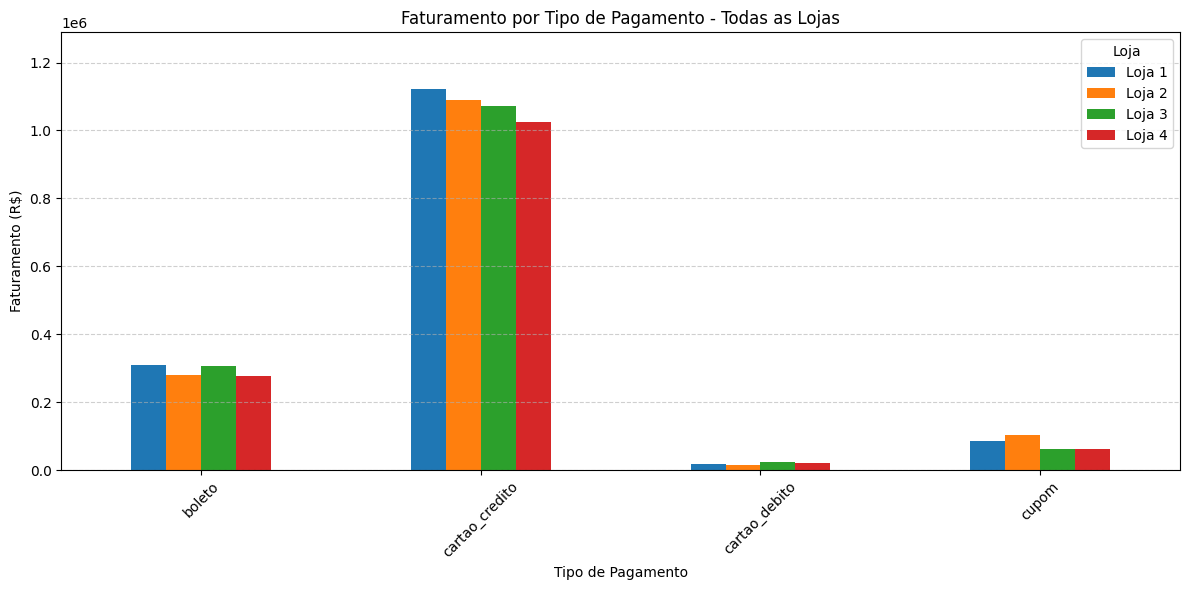

In [41]:


# Dados
lojas = {
    'Loja 1': loja,
    'Loja 2': loja2,
    'Loja 3': loja3,
    'Loja 4': loja4
}

# Coletar os dados em um único DataFrame
dados_grafico = pd.DataFrame()

for nome_loja, df_loja in lojas.items():
    grupo = df_loja.groupby('Tipo de pagamento')['Preço'].sum()
    grupo.name = nome_loja
    dados_grafico = pd.concat([dados_grafico, grupo], axis=1)

# Substituir valores NaN por 0
dados_grafico = dados_grafico.fillna(0)

# Criar gráfico de barras agrupado
ax = dados_grafico.plot(kind='bar', figsize=(12, 6))
plt.title('Faturamento por Tipo de Pagamento - Todas as Lojas')
plt.xlabel('Tipo de Pagamento')
plt.ylabel('Faturamento (R$)')
plt.xticks(rotation=45)
plt.legend(title='Loja')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Ajustar o limite do eixo Y para exibir tudo
max_value = dados_grafico.max().max()
ax.set_ylim(0, max_value * 1.15)

plt.tight_layout()
plt.show()


# **2. Vendas por Categoria**

In [42]:

def analisar_vendas_por_categoria(df, nome_loja):
    # Agrupar por categoria e calcular as métricas
    analise = df.groupby('Categoria do Produto').agg(
        numero_de_vendas=('Produto', 'count'),
        faturamento_total=('Preço', 'sum')
    ).reset_index()

    # Calcular totais
    total_vendas = analise['numero_de_vendas'].sum()
    total_faturamento = analise['faturamento_total'].sum()

    # Calcular porcentagem
    analise['porcentagem'] = (analise['numero_de_vendas'] / total_vendas) * 100

    # Ordenar por número de vendas (decrescente)
    analise = analise.sort_values('numero_de_vendas', ascending=False)

    # Adicionar linha de totais
    total_row = pd.DataFrame({
        'Categoria do Produto': ['TOTAL'],
        'numero_de_vendas': [total_vendas],
        'faturamento_total': [total_faturamento],
        'porcentagem': [100.00]
    })

    analise = pd.concat([analise, total_row], ignore_index=True)

    # Formatação
    analise['faturamento_total'] = analise['faturamento_total'].apply(lambda x: f'R$ {x:,.2f}')
    analise['porcentagem'] = analise['porcentagem'].apply(lambda x: f'{x:.2f}%')

    # Adicionar nome da loja
    analise['Loja'] = nome_loja

    return analise

# Aplicar a função para cada loja
tabela_loja1 = analisar_vendas_por_categoria(loja, 'Loja 1')
tabela_loja2 = analisar_vendas_por_categoria(loja2, 'Loja 2')
tabela_loja3 = analisar_vendas_por_categoria(loja3, 'Loja 3')
tabela_loja4 = analisar_vendas_por_categoria(loja4, 'Loja 4')

# Exibir as tabelas
print("Tabela Loja 1:")
display(tabela_loja1)

print("\nTabela Loja 2:")
display(tabela_loja2)

print("\nTabela Loja 3:")
display(tabela_loja3)

print("\nTabela Loja 4:")
display(tabela_loja4)

Tabela Loja 1:


,Categoria do Produto,numero_de_vendas,faturamento_total,porcentagem,Loja
0,moveis,465,"R$ 250,178.11",19.71%,Loja 1
1,eletronicos,448,"R$ 572,659.23",18.99%,Loja 1
2,brinquedos,324,"R$ 23,993.78",13.73%,Loja 1
3,eletrodomesticos,312,"R$ 484,913.36",13.23%,Loja 1
4,esporte e lazer,284,"R$ 52,387.55",12.04%,Loja 1
5,instrumentos musicais,182,"R$ 121,731.69",7.72%,Loja 1
6,livros,173,"R$ 11,713.92",7.33%,Loja 1
7,utilidades domesticas,171,"R$ 16,931.48",7.25%,Loja 1
8,TOTAL,2359,"R$ 1,534,509.12",100.00%,Loja 1



Tabela Loja 2:


,Categoria do Produto,numero_de_vendas,faturamento_total,porcentagem,Loja
0,moveis,442,"R$ 235,234.68",18.74%,Loja 2
1,eletronicos,422,"R$ 547,773.71",17.89%,Loja 2
2,brinquedos,313,"R$ 21,262.21",13.27%,Loja 2
3,eletrodomesticos,305,"R$ 464,758.13",12.93%,Loja 2
4,esporte e lazer,275,"R$ 46,326.09",11.66%,Loja 2
5,instrumentos musicais,224,"R$ 139,987.03",9.50%,Loja 2
6,livros,197,"R$ 13,454.35",8.35%,Loja 2
7,utilidades domesticas,181,"R$ 19,662.86",7.67%,Loja 2
8,TOTAL,2359,"R$ 1,488,459.06",100.00%,Loja 2



Tabela Loja 3:


,Categoria do Produto,numero_de_vendas,faturamento_total,porcentagem,Loja
0,moveis,499,"R$ 268,095.56",21.15%,Loja 3
1,eletronicos,451,"R$ 547,699.92",19.12%,Loja 3
2,brinquedos,315,"R$ 25,869.20",13.35%,Loja 3
3,eletrodomesticos,278,"R$ 438,984.89",11.78%,Loja 3
4,esporte e lazer,277,"R$ 47,456.10",11.74%,Loja 3
5,livros,185,"R$ 12,664.70",7.84%,Loja 3
6,instrumentos musicais,177,"R$ 103,174.45",7.50%,Loja 3
7,utilidades domesticas,177,"R$ 20,080.21",7.50%,Loja 3
8,TOTAL,2359,"R$ 1,464,025.03",100.00%,Loja 3



Tabela Loja 4:


,Categoria do Produto,numero_de_vendas,faturamento_total,porcentagem,Loja
0,moveis,480,"R$ 256,705.65",20.36%,Loja 4
1,eletronicos,451,"R$ 545,966.86",19.13%,Loja 4
2,brinquedos,338,"R$ 27,015.67",14.33%,Loja 4
3,esporte e lazer,277,"R$ 44,465.65",11.75%,Loja 4
4,eletrodomesticos,254,"R$ 377,680.65",10.77%,Loja 4
5,utilidades domesticas,201,"R$ 20,098.83",8.52%,Loja 4
6,livros,187,"R$ 12,427.77",7.93%,Loja 4
7,instrumentos musicais,170,"R$ 100,136.50",7.21%,Loja 4
8,TOTAL,2358,"R$ 1,384,497.58",100.00%,Loja 4


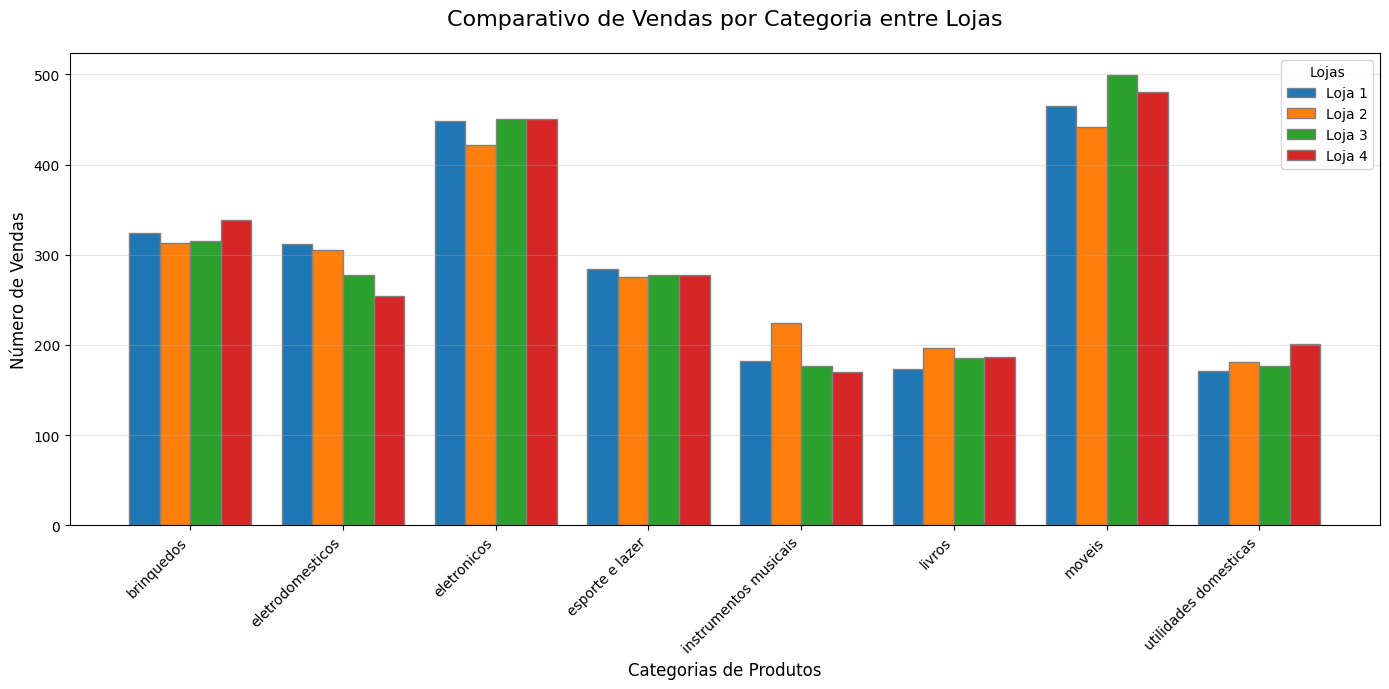

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Função para extrair os dados das suas tabelas
def preparar_dados_grafico(*tabelas):
    # Pegar todas as categorias únicas (excluindo a linha 'TOTAL')
    categorias = []
    for tabela in tabelas:
        cats = tabela[tabela['Categoria do Produto'] != 'TOTAL']['Categoria do Produto'].unique()
        categorias.extend(cats)
    categorias = list(set(categorias))  # Remover duplicatas

    # Criar estrutura de dados
    dados = {
        'categorias': sorted(categorias),
        'lojas': ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4'],
        'vendas': []
    }

    # Preencher com os valores de cada loja
    for tabela in tabelas:
        vendas_por_categoria = []
        for cat in dados['categorias']:
            # Encontrar o valor na tabela correspondente
            valor = tabela.loc[tabela['Categoria do Produto'] == cat, 'numero_de_vendas']
            vendas_por_categoria.append(valor.values[0] if not valor.empty else 0)
        dados['vendas'].append(vendas_por_categoria)

    return dados

# Preparar os dados para o gráfico
dados = preparar_dados_grafico(tabela_loja1, tabela_loja2, tabela_loja3, tabela_loja4)

# Configurar o gráfico
plt.figure(figsize=(14, 7))
bar_width = 0.2
x = np.arange(len(dados['categorias']))

# Cores para cada loja
cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Plotar as barras para cada loja
for i, loja in enumerate(dados['lojas']):
    plt.bar(
        x + i * bar_width,
        dados['vendas'][i],
        width=bar_width,
        label=loja,
        color=cores[i],
        edgecolor='grey'
    )

# Personalização do gráfico
plt.title('Comparativo de Vendas por Categoria entre Lojas', fontsize=16, pad=20)
plt.xlabel('Categorias de Produtos', fontsize=12)
plt.ylabel('Número de Vendas', fontsize=12)
plt.xticks(x + bar_width * 1.5, dados['categorias'], rotation=45, ha='right')
plt.legend(title='Lojas')
plt.grid(axis='y', alpha=0.3)

# Ajustar layout e mostrar
plt.tight_layout()
plt.show()

# **3. Média de Avaliação das Lojas**

In [46]:
from IPython.display import display
# Dados
lojas = {
    'Loja 1': loja,
    'Loja 2': loja2,
    'Loja 3': loja3,
    'Loja 4': loja4
}

# Lista para armazenar os resultados
dados_avaliacoes = []

# Processa cada loja
for nome_loja, df_loja in lojas.items():
    media = df_loja['Avaliação da compra'].mean()
    qtd = df_loja['Avaliação da compra'].count()
    dados_avaliacoes.append([nome_loja, round(media, 2), qtd])

# Criar DataFrame com os resultados
tabela_avaliacoes = pd.DataFrame(dados_avaliacoes, columns=['Loja', 'Média', 'Qtd_Avaliações'])

# Exibir a tabela formatada
display(tabela_avaliacoes)

,Loja,Média,Qtd_Avaliações
0,Loja 1,3.98,2359
1,Loja 2,4.04,2359
2,Loja 3,4.05,2359
3,Loja 4,4.00,2358


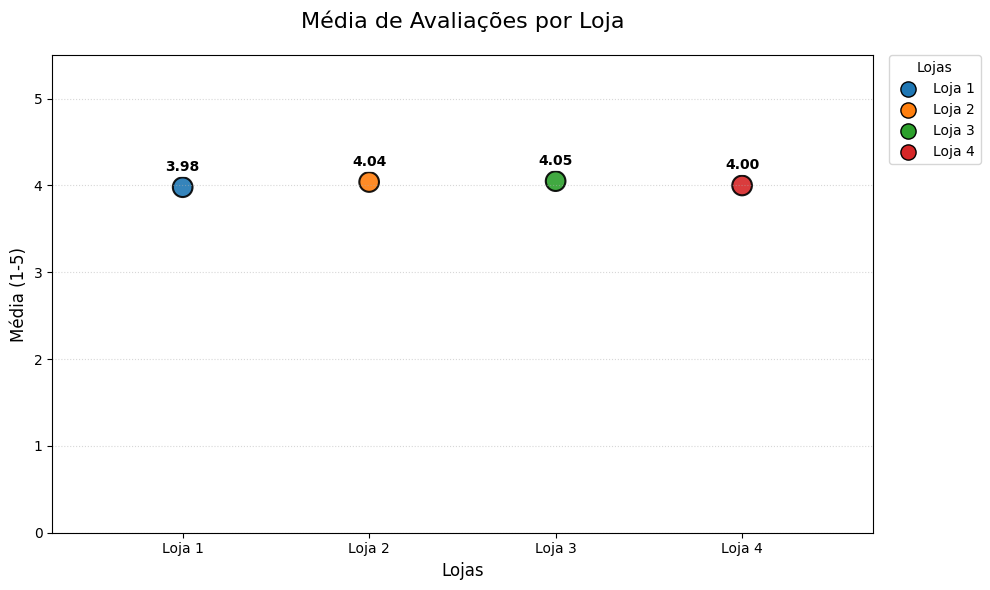

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Dados
lojas = tabela_avaliacoes['Loja']
medias = tabela_avaliacoes['Média']
cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Criar o gráfico de dispersão
plt.figure(figsize=(10, 6))

# Criar eixos X numéricos para posicionamento
x_pos = np.arange(len(lojas))

# Plotar os pontos com bordas pretas
plt.scatter(x_pos, medias, c=cores, s=200, alpha=0.9, edgecolors='black', linewidth=1.5)

# Adicionar rótulos e título
plt.title('Média de Avaliações por Loja', fontsize=16, pad=20)
plt.xlabel('Lojas', fontsize=12)
plt.ylabel('Média (1-5)', fontsize=12)

# Configurar eixo X
plt.xticks(x_pos, lojas)

# Adicionar valores aos pontos
for x, y, loja in zip(x_pos, medias, lojas):
    plt.text(x, y + 0.15, f'{y:.2f}',
             ha='center', va='bottom',
             fontsize=10,
             fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

# Ajustes visuais
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.ylim(0, 5.5)
plt.xlim(-0.7, len(lojas)-0.3)  # Margens mais amplas

# Adicionar legenda colorida
for i, loja in enumerate(lojas):
    plt.scatter([], [], c=cores[i], s=120, label=loja, edgecolors='black')
plt.legend(title='Lojas', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

# **4. Produtos Mais e Menos Vendidos**

In [50]:
import pandas as pd
from IPython.display import display

# Função para formatar valores monetários
def formatar_reais(valor):
    return f"R${valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

# Dicionário com os DataFrames de cada loja
lojas = {
    'Loja 1': loja,
    'Loja 2': loja2,
    'Loja 3': loja3,
    'Loja 4': loja4
}

# Processar cada loja
for nome_loja, df_loja in lojas.items():
    # Contar ocorrências por produto (cada linha = 1 venda)
    vendas_por_produto = df_loja['Produto'].value_counts().reset_index()
    vendas_por_produto.columns = ['Produto', 'Vendas']

    # Calcular faturamento por produto
    faturamento_por_produto = df_loja.groupby('Produto')['Preço'].sum().reset_index()

    # Combinar os dados
    dados_produtos = pd.merge(vendas_por_produto, faturamento_por_produto, on='Produto')

    # Identificar mais e menos vendidos
    mais_vendido = dados_produtos.loc[dados_produtos['Vendas'].idxmax()]
    menos_vendido = dados_produtos.loc[dados_produtos['Vendas'].idxmin()]

    # Criar tabela de resultados
    resultado = pd.DataFrame({
        'Loja': [nome_loja, nome_loja],
        'Destaque': ['Mais Vendido', 'Menos Vendido'],
        'Produto': [mais_vendido['Produto'], menos_vendido['Produto']],
        'Vendas': [mais_vendido['Vendas'], menos_vendido['Vendas']],
        'Faturamento': [mais_vendido['Preço'], menos_vendido['Preço']]
    })

    # Formatar faturamento
    resultado['Faturamento'] = resultado['Faturamento'].apply(formatar_reais)

    # Exibir tabela
    display(resultado)
    print("\n" + "="*50 + "\n")  # Separador entre lojas

,Loja,Destaque,Produto,Vendas,Faturamento
0,Loja 1,Mais Vendido,Micro-ondas,60,"R$46.348,89"
1,Loja 1,Menos Vendido,Headset,33,"R$6.307,71"


,Loja,Destaque,Produto,Vendas,Faturamento
0,Loja 2,Mais Vendido,Iniciando em programação,65,"R$4.169,96"
1,Loja 2,Menos Vendido,Jogo de tabuleiro,32,"R$7.749,58"


,Loja,Destaque,Produto,Vendas,Faturamento
0,Loja 3,Mais Vendido,Kit banquetas,57,"R$22.265,96"
1,Loja 3,Menos Vendido,Blocos de montar,35,"R$1.649,81"


,Loja,Destaque,Produto,Vendas,Faturamento
0,Loja 4,Mais Vendido,Cama box,62,"R$43.928,57"
1,Loja 4,Menos Vendido,Guitarra,33,"R$34.430,67"


# **5. Media Frete**

In [51]:
# Adiciona uma coluna 'Loja' em cada DataFrame
loja['Loja'] = 'Loja 1'
loja2['Loja'] = 'Loja 2'
loja3['Loja'] = 'Loja 3'
loja4['Loja'] = 'Loja 4'

# Combina todos os DataFrames
dados_completos = pd.concat([loja, loja2, loja3, loja4], ignore_index=True)

# Calcula o frete médio por loja
resumo_frete = dados_completos.groupby('Loja')['Frete'].agg(['mean']).round(2)
resumo_frete = resumo_frete.rename(columns={'mean': 'Frete Médio (R$)'})

# Exibe o resultado com display (ideal para Jupyter Notebook)
display(resumo_frete)

,Frete Médio (R$)
Loja,
Loja 1,34.69
Loja 2,33.62
Loja 3,33.07
Loja 4,31.28


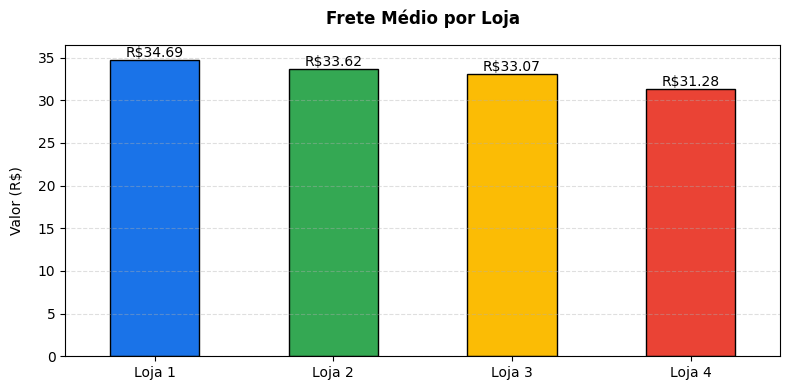

In [52]:


# 1. Juntar todos os dados
dados = pd.concat([
    loja.assign(Loja='Loja 1'),
    loja2.assign(Loja='Loja 2'),
    loja3.assign(Loja='Loja 3'),
    loja4.assign(Loja='Loja 4')
])

# 2. Calcular frete médio
frete_medio = dados.groupby('Loja')['Frete'].mean()

# 3. Criar gráfico
plt.figure(figsize=(8, 4))
ax = frete_medio.plot(kind='bar', color=['#1a73e8', '#34a853', '#fbbc05', '#ea4335'], edgecolor='black')

# 4. Personalização
plt.title('Frete Médio por Loja', fontweight='bold', pad=15)
plt.xlabel('')
plt.ylabel('Valor (R$)', labelpad=10)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Adicionar valores nas barras
for p in ax.patches:
    ax.annotate(f'R${p.get_height():.2f}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Analise **geral**

In [53]:


# Faturamento
faturamentos = {
    'Loja 1': faturamento_loja1,
    'Loja 2': faturamento_loja2,
    'Loja 3': faturamento_loja3,
    'Loja 4': faturamento_loja4
}

# Número de produtos vendidos
vendas = {
    'Loja 1': tabela_loja1[tabela_loja1['Categoria do Produto'] == 'TOTAL']['numero_de_vendas'].values[0],
    'Loja 2': tabela_loja2[tabela_loja2['Categoria do Produto'] == 'TOTAL']['numero_de_vendas'].values[0],
    'Loja 3': tabela_loja3[tabela_loja3['Categoria do Produto'] == 'TOTAL']['numero_de_vendas'].values[0],
    'Loja 4': tabela_loja4[tabela_loja4['Categoria do Produto'] == 'TOTAL']['numero_de_vendas'].values[0],
}

# Médias de avaliação e quantidade de avaliações
avaliacoes_dict = tabela_avaliacoes.set_index('Loja').to_dict(orient='index')

# Frete médio
fretes = resumo_frete['Frete Médio (R$)'].to_dict()

# Faturamento total
faturamento_total = sum(faturamentos.values())

# --- Montar a tabela final ---
dados_finais = []

for loja in ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']:
    fat = faturamentos[loja]
    perc = calcular_porcentagem(fat, faturamento_total)
    produtos = vendas[loja]
    media_aval = avaliacoes_dict[loja]['Média']
    qtd_aval = avaliacoes_dict[loja]['Qtd_Avaliações']
    frete_medio = fretes[loja]

    dados_finais.append([
        loja,
        formatar_em_reais(fat),
        f'{perc:.2f}%',
        produtos,
        media_aval,
        qtd_aval,
        frete_medio
    ])

# Criar DataFrame
tabela_final = pd.DataFrame(dados_finais, columns=[
    'Loja', 'Faturamento', '% do Faturamento',
    'Produtos Vendidos', 'Média Avaliação', 'Qtd. Avaliações', 'Frete Médio (R$)'
])

# Adicionar linha de totais
linha_total = pd.DataFrame([[
    'Total',
    formatar_em_reais(faturamento_total),
    '100.00%',
    sum(vendas.values()),
    '-', '-', '-'  # Não se aplica para médias
]], columns=tabela_final.columns)

# Concatenar
tabela_final = pd.concat([tabela_final, linha_total], ignore_index=True)

# Exibir
display(tabela_final)


,Loja,Faturamento,% do Faturamento,Produtos Vendidos,Média Avaliação,Qtd. Avaliações,Frete Médio (R$)
0,Loja 1,"R$ 1,534,509.12",26.13%,2359,3.98,2359,34.69
1,Loja 2,"R$ 1,488,459.06",25.35%,2359,4.04,2359,33.62
2,Loja 3,"R$ 1,464,025.03",24.93%,2359,4.05,2359,33.07
3,Loja 4,"R$ 1,384,497.58",23.58%,2358,4.0,2358,31.28
4,Total,"R$ 5,871,490.79",100.00%,9435,-,-,-


# Considerações finais

## **Análise das Lojas com Base nos Dados Fornecidos pelo Sr. João**

Com base nos dados das quatro lojas fornecidos pelo Sr. João, realizamos uma análise considerando os seguintes pontos:

### **1. Faturamento Total das Lojas**

A Loja 1 apresentou o maior faturamento: R$ 1.534.509,12

A Loja 4 teve o menor faturamento: R$ 1.384.497,58

A diferença entre a loja com maior e menor faturamento foi de R$ 150.011,54

### **2. Vendas por Categoria**

Foi analisada a quantidade de vendas por categoria em cada loja, identificando quais produtos tiveram maior e menor saída.

### **3. Média de Avaliação dos Clientes**

Loja 1: 3,98

Loja 2: 4,04

Loja 3: 4,05

Loja 4: 4,00
A Loja 3 obteve a melhor avaliação, enquanto a Loja 1 teve a menor.

### **4. Análise de Produtos Vendidos**

Identificamos quais foram os produtos mais e menos vendidos em cada loja.

### **5. Valor Médio do Frete por Loja**

Loja 1: R$ 34,69

Loja 2: R$ 33,62

Loja 3: R$ 33,07

Loja 4: R$ 31,28

A Loja 4 teve o menor custo médio de frete entre todas.

### **Considerando tudo isso**

A melhor escolha para ser vendida é a Loja 4. Isso se baseia em alguns fatores importantes analisados: ela teve o menor faturamento entre as quatro lojas, representando 23,58% do total, com uma diferença de R$ 150.011,54 em relação à loja que mais faturou. Mesmo tendo um número de produtos vendidos parecido com o da loja líder em faturamento, a Loja 4 não converteu essas vendas em receita da mesma forma, o que mostra um desempenho financeiro abaixo das demais.

Além disso, a Loja 4 teve o menor valor de frete,o que seria algo positivo mas não converteu em receita, e ficou com a segunda pior avaliação, o que também pode afetar negativamente as vendas e a confiança dos clientes.

Por esses motivos, vender a Loja 4 parece ser a decisão mais adequada no momento.
